# Task 4g: 'Event Type'

In this notebook, we are adding a new feature called **“Event Type”** that searches for keywords regarding type of phenomenon.

It classifies the event based on the description into one of several predefined categories based on specific keywords:
- Murder
- Suicide
- Accident
- Supernatural

If a category is not discernable, it will return **"Unknown"**. 


In [5]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [28]:
# Define a function to extract event type
def extract_event_type(description):
    # Convert description to lowercase for case-insensitive matching
    description = description.lower()
    
    # Define keywords for each event type
    event_keywords = {
        'Murder': [
            'murder', 'killed', 'homicide', 'slain', 'assassination', 'execution',
            'stabbed', 'shot', 'strangled', 'poisoned', 'beaten', 'bludgeoned',
            'massacre', 'manslaughter', 'foul play', 'violent death', 'brutal death',
        ],
        'Suicide': [
            'suicide', 'took their own life', 'ended their life', 'self-inflicted',
            'hanged', 'overdose', 'jumped', 'self-harm', 'self-destruction',
        ],
        'Accident': [
            'accident', 'crash', 'collision', 'fall', 'drowned', 'burned', 'electrocuted',
            'explosion', 'fire', 'train wreck', 'car crash', 'plane crash', 'industrial accident',
        ],
        'Death': [
            'died', 'death', 'passed away', 'deceased', 'perished', 'lost their life',
            'killed', 'dead', 'fatality', 'mortality', 'demise', 'expired',
        ],
        'Supernatural': [
            'supernatural', 'paranormal', 'ghost', 'spirit', 'phantom', 'apparition',
            'haunting', 'haunted', 'poltergeist', 'specter', 'wraith', 'entity',
            'otherworldly', 'ethereal', 'mystical', 'occult', 'demonic', 'satanic',
            'witchcraft', 'curse', 'hex', 'possession', 'exorcism', 'supernatural phenomenon',
        ],
        'Violence': [
            'violence', 'assault', 'attack', 'brawl', 'fight', 'riot', 'war', 'battle',
            'shooting', 'stabbing', 'beating', 'abuse', 'torture', 'hostage', 'kidnapping',
            'robbery', 'theft', 'vandalism', 'destruction', 'rampage', 'mass shooting',
        ],
        'Mystery': [
            'mystery', 'unsolved', 'unexplained', 'strange', 'bizarre', 'enigma',
            'puzzle', 'riddle', 'curious', 'peculiar', 'odd', 'weird', 'unusual',
            'anomaly', 'phenomenon', 'unidentified', 'unknown', 'secret', 'hidden',
        ],
        'Natural Disaster': [
            'earthquake', 'tsunami', 'hurricane', 'tornado', 'flood', 'volcano',
            'landslide', 'avalanche', 'drought', 'famine', 'plague', 'pandemic',
            'epidemic', 'storm', 'lightning', 'wildfire', 'blizzard', 'cyclone',
            'typhoon', 'natural disaster',
        ],
    }
    
    # Check for each event type in order of specificity
    for event_type, keywords in event_keywords.items():
        if any(keyword in description for keyword in keywords):
            return event_type
    
    # If no event type is found, return "Unknown"
    return "Unknown"

# Add the new feature
haunted_places['Event Type'] = haunted_places['description'].apply(extract_event_type)

In [33]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

# Analysis & Visualizations 
We can examine the percentage of identified **"Event Types** from the dataset. </br>
The number of entries with *known* apparition type is 8451 (**76.88%**) entries of the dataset. 

The first graph below shows us the ratio of descriptions with more identifiable features and apparation types 

The second graph visualizes the event type based on certain keywords. The events are classified into types of events that are commonly associated with haunted places: 
- Murder
- Suicide
- Accident
- Death
- Supernatural Phenomena
- Violence
- Mystery
- Natural Disaster

In [35]:
total_entries = len(haunted_places)

# Count the number of "Known" event types (i.e., non-Unknown)
unknown_count = (haunted_places['Event Type'] == 'Unknown').sum()
known_count = total_entries - unknown_count


# Calculate percentages
unknown_percentage = (unknown_count / total_entries) * 100
known_percentage = (known_count / total_entries) * 100

# Print the results
print(f"Number of entries with 'Unknown' event type: {unknown_count} ({unknown_percentage:.2f}%)")
print(f"Number of entries with 'Known' event type: {known_count} ({known_percentage:.2f}%)")


Number of entries with 'Unknown' event type: 2541 (23.12%)
Number of entries with 'Known' event type: 8451 (76.88%)


## Graph 1: Known vs Unknown Event Types

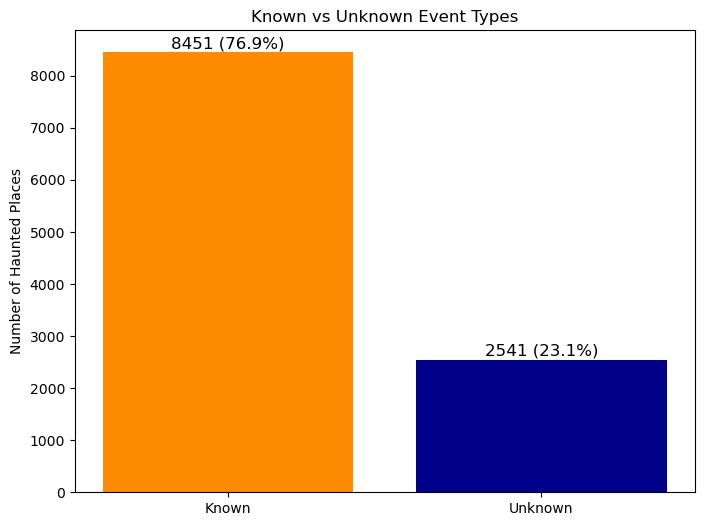

In [46]:
# Count the number of "Known" event types (i.e., non-Unknown)
known_count = len(haunted_places) - (haunted_places['Event Type'] == 'Unknown').sum()
unknown_count = (haunted_places['Event Type'] == 'Unknown').sum()

# Data for the bar chart
labels = ['Known', 'Unknown']
counts = [known_count, unknown_count]

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['darkorange', 'darkblue'])

# Add text (count + percentage) on top of each bar
total_entries = len(haunted_places)
for bar, count in zip(bars, counts):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,  
             f'{count} ({percentage:.1f}%)', ha='center', va='bottom', fontsize=12, color='black')

# Labels and title
plt.ylabel('Number of Haunted Places')
plt.title('Known vs Unknown Event Types')
plt.show()


## Graph 2: Distribution of Event Categories

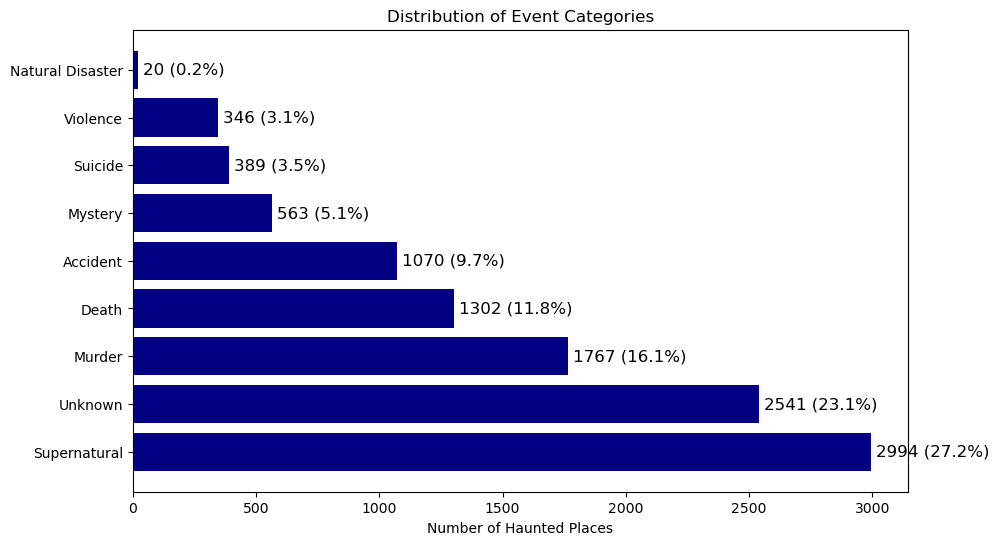

In [59]:
# Count the number of occurrences of each event category
event_category_counts = haunted_places['Event Type'].value_counts()

# Create the horizontal bar chart for event categories
plt.figure(figsize=(10, 6))
bars = plt.barh(event_category_counts.index, event_category_counts.values, color='navy')

# Add text (count + percentage) on top of each bar
total_entries = len(haunted_places)
for bar, count in zip(bars, event_category_counts.values):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,  # Adjust position of text for horizontal bars
             f'{count} ({percentage:.1f}%)', va='center', fontsize=12, color='black')

# Labels and title
plt.xlabel('Number of Haunted Places')
plt.title('Distribution of Event Categories')
plt.show()
